# Look into the Data

In [1]:
import pandas as pd
import numpy as np
DF = pd.read_csv("RawData/products.csv")
DF.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [2]:
DF.count()

product_id       49688
product_name     49688
aisle_id         49688
department_id    49688
dtype: int64

In [3]:
DF.isna().any()

product_id       False
product_name     False
aisle_id         False
department_id    False
dtype: bool

In [4]:
len(np.unique(DF.aisle_id))

134

In [5]:
len(np.unique(DF.department_id))

21

In [6]:
Longest_product_name = np.max(DF.product_name.apply(lambda x: len(x.split(" "))))
Longest_product_name

np.int64(27)

# Choose and Initialized Pre-Trained BERT

In [7]:
import transformers
bert_name = 'bert-base-uncased'
tokenizer = transformers.BertTokenizer.from_pretrained(bert_name)
bert_model = transformers.BertModel.from_pretrained(bert_name)

# Tokenizer Performance

In [8]:
from annoy import AnnoyIndex
embedding_length = 30

def tokenize(x, max_length = embedding_length):
    return tokenizer.encode_plus(x, max_length = max_length, padding = "max_length", truncation = True)["input_ids"]

AnnoyTree = AnnoyIndex(embedding_length, "euclidean")

In [9]:
from tqdm import tqdm
for i in tqdm(range(DF.shape[0])):
    ID = DF.iloc[i, 0]
    Text = DF.iloc[i, 1]
    Embedding = tokenize(Text)
    AnnoyTree.add_item(ID, Embedding)

100%|██████████████████████████████████████████████████████████████████████████| 49688/49688 [00:12<00:00, 3885.45it/s]


In [10]:
AnnoyTree.build(20)
AnnoyTree.save("annoy/tokenizer.ann")
AnnoyTree.unload()

True

In [11]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def DimReduced_Plot(embedded, data_points = 100, dimensions = 3):
    if dimensions < 2 or dimensions > 3:
        print("Please set 'dimensions = 2' for 2d-plots or 'dimensions = 3' for 3d-plots")
    else:
        aisles = DF.loc[:, "aisle_id"].iloc[:data_points]
        departments = DF.loc[:, "department_id"].iloc[:data_points]
    
        pca = PCA(n_components = dimensions)
        tsne = TSNE(n_components = dimensions)
    
        embedded_pca = pca.fit_transform(embedded)
        embedded_tsne = tsne.fit_transform(embedded)
    
        #### the plots
        plot_number = 0
        fig = plt.figure(figsize = (10, 10))
        for ID, ID_name in zip([aisles, departments], ["aisles", "departments"]):
            for dim_red, dim_red_name in zip([embedded_pca, embedded_tsne], ["PCA", "TSNE"]):
                plot_number += 1
                if dimensions == 2:
                    ax = fig.add_subplot(2, 2, plot_number)
                    ax.scatter(x = dim_red[:, 0], y = dim_red[:, 1], c = ID)
                else:
                    ax = fig.add_subplot(2, 2, plot_number,  projection='3d')
                    ax.scatter(xs = dim_red[:, 0], ys = dim_red[:, 1], zs = dim_red[:, 2], c = ID)
                ax.set_title(f"Reduction with {dim_red_name}.\nColored according to {ID_name}")
        plt.show()
            

In [12]:
data_points = 100
word_embedded = np.array(DF.iloc[:data_points, 1].apply(lambda x: tokenize(x)).to_list())

C:\Users\flash\anaconda3\envs\ML_Pytorch\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


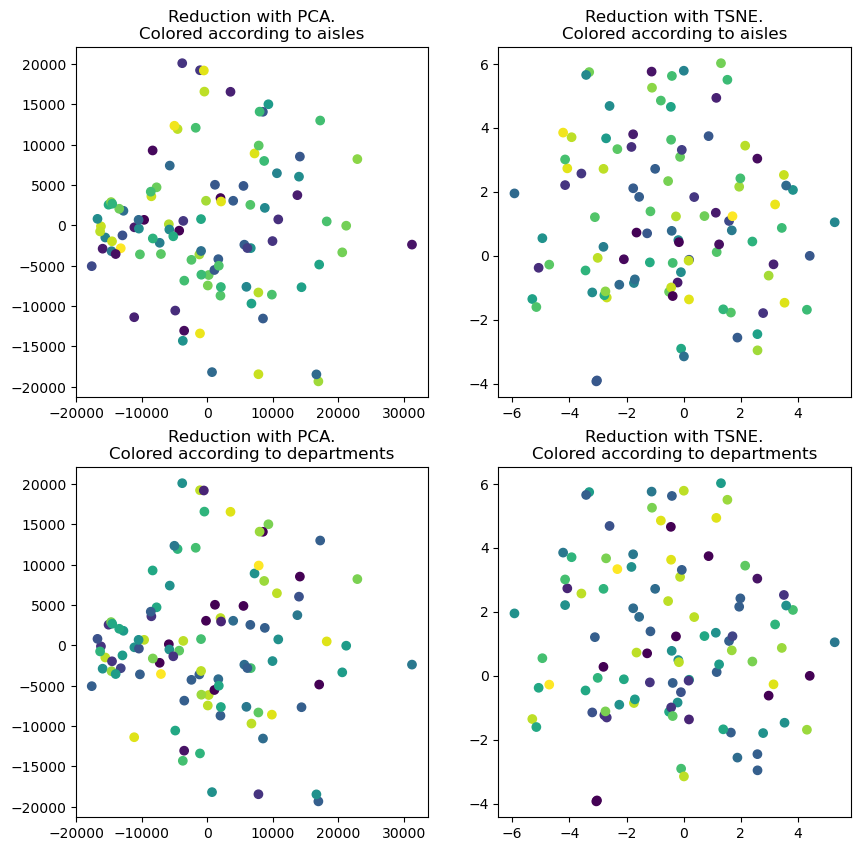

In [13]:
DimReduced_Plot(word_embedded, data_points = data_points, dimensions = 2)

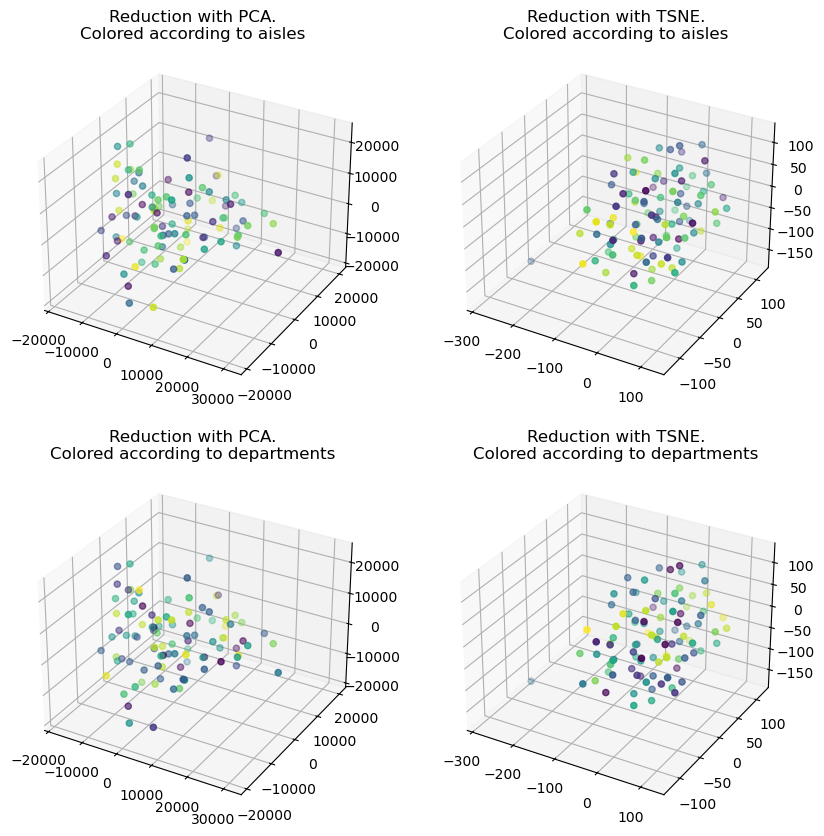

In [14]:
DimReduced_Plot(word_embedded, data_points = data_points, dimensions = 3)

In [15]:
def show_n_neighbors(filename, n_neighbors = 10, n_samples = 5000, embedding_length = embedding_length, id_list = DF.product_id):
    AnnoyTree = AnnoyIndex(embedding_length, "euclidean")
    AnnoyTree.load(f"annoy/{filename}")

    random_ids = np.random.choice(id_list, size = n_samples, replace = False)
    nested_list = []
    aisle_acc = 0
    department_acc = 0
    total_number = n_neighbors * n_samples
    for ID in random_ids:
        neighbor_ids = AnnoyTree.get_nns_by_item(ID, n_neighbors+1) # the first neighbors is always the ID itself
        neighbors = []
        # The first ID which is the ID I wanted to have the neighbors of
        mask = DF.product_id == neighbor_ids[0]
        name = DF.loc[mask, "product_name"].iloc[0]
        correct_aisle = DF.loc[mask, "aisle_id"].iloc[0]
        correct_department = DF.loc[mask, "department_id"].iloc[0]
        neighbors.append(name)
        # The neighbors
        for i in neighbor_ids[1:]:
            mask = DF.product_id == i
            name = DF.loc[mask, "product_name"].iloc[0]
            aisle = DF.loc[mask, "aisle_id"].iloc[0]
            department = DF.loc[mask, "department_id"].iloc[0]
            aisle_acc += int(correct_aisle == aisle)
            department_acc += int(correct_department == department)
            neighbors.append(name)
        neighbors = [ID] + neighbors
        nested_list.append(neighbors)

    print(f"{aisle_acc/total_number:.2%} of neighbors are in the same aisle as the query product")
    print(f"{department_acc/total_number:.2%} of neighbors are in the same department as the query product")
    as_DF = pd.DataFrame(np.array(nested_list[:10]), columns = ["Product_ID", "Product_Name"] + [f"Closest_Neighbor {i}" for i in range(1, n_neighbors+1)])
    return as_DF

closest_neighbors_df = show_n_neighbors("tokenizer.ann")
closest_neighbors_df

5.59% of neighbors are in the same aisle as the query product
13.07% of neighbors are in the same department as the query product


,Product_ID,Product_Name,Closest_Neighbor 1,Closest_Neighbor 2,Closest_Neighbor 3,Closest_Neighbor 4,Closest_Neighbor 5,Closest_Neighbor 6,Closest_Neighbor 7,Closest_Neighbor 8,Closest_Neighbor 9,Closest_Neighbor 10
0,12998,Organic Du Puy Lentils,Organic Black Bean Lower Sodium Soup,Leafy Romaine Salad Blend,Organic Honey Lemon Manuka Drops,Instant Coffee Crystals Classic Decaf,Fresh Pressed Pomegranate,Breakfast Veggie Bacon Strips,Organic Italian Vegetables and Beans Soup,Organic Garden Vegetables with Herbs Soup,Organic Elevate Juice Blend,Organic Veggies Snack Tray
1,35706,Ancient Grains Bread,Health Nut Bread,Square Dessert Plates,Hard Boiled Eggs,Ear Drying Drops,Asian Salad Kit,Italian Sliced Bread,Original Salad Cream,Sweet Sliced Bread,Carob Chip,French Sliced Bread
2,49545,Vegan Ultra Omega 3 Flax Oil Epa + Dha With Vi...,Vegan Conditioner Nourishing Non GMO Hemp + Ar...,"YoKids Squeezers Organic Low-Fat Yogurt, Straw...",No Sugar Added Diced Peaches-Diced Pears & Man...,"Beverage, Love Greens, Chia & Greens, Beet & G...","Soybean Paste (White), Shiro Miso Instant Soup",Grab and Go Pulp Free 100% Pure Calcium & Vita...,B12 1000mcg Liquid Sublingual Drops Raspberry ...,"Hint of Mint, Rich Chocolate with a Splash of ...",with Xylitol Minty Sweet Twist 18 Sticks Sugar...,Cough+Chest Congestion Dm Non Drowsy Syrup
3,33688,Water Essentia Sportscap,Summer Pear Sparking Beverage,Probiotic Dairy Culture Strawberry,Natural Mango Essenced Sparkling Water,Hot Salsa Brava Sauce,Split Pea Soup Low Sodium,Shortbread Sugar Free Cookies,Best Refried Black Beans,"Licorice, Strawberry",Green Chilly Beef & Bean,Classic Roast Instant Coffee Crystals
4,48675,Tall Kitchen Drawstring Bag Island Fresh,Heavy Duty Aluminum Foil 50 Sq. Ft.,Body Deodorant Roll-On,Organic AppleBerry Applesauce on the Go,Fun Size Candy Snack 6 Count,Fat Free Chocolate Flavored Fat Free Milk,Original Witch Hazel Pore Perfecting Toner,Organic Whole Wheat Rigatoni No. 7,Grow Well Tummy Baby Food,Totz Toothbrush Extra Soft 18+ Months,1F Organic Apples Organic Purees Fruit
5,22887,Skillet Sauce Thick Curry Chicken,Organic Kids Berry Pink Lemonade,Organic 21 Grain Thin Sliced Bread,Organic Honey Lemon Manuka Drops,Organic Black Bean Lower Sodium Soup,Organic Mixed Berry Apple Sauce Cups,Organic Italian Vegetables and Beans Soup,Organic Garden Vegetables with Herbs Soup,Organic Red Lentil Rotini,Instant Coffee Crystals Classic Decaf,Cheeky Lemon Organic Lemon Drops
6,28952,Vitamin C,Vitamin D,Tablets,Brandy,Rosemary,Apples,Peach,Gin,Burgundy,Strawberry,Walnuts
7,20583,Sourdough Baguette,Lemon Iced Tea Mix Packets,Calcium Citrate Magnesium Plus,Lemon Scented Room Freshener,Sourdough Bachelor Loaf,Peach Iced Tea Mix Packets,Sprouted Hot Dog Buns,Sourdough Round Loaf,Hazelnut Spread with Cocoa,Oven Roasted Sea Salt Almonds,Orecchiette Dry Pasta
8,35083,Manuka Honey Bio Active 5+,Traditional Masala Chai,Traditional Hummus Dip,White Cone Coffee Filters Size 4,Whole Bean Holiday Blend Coffee,Original Mashed Potatoes,Soft Baked Sugar Cookies,Yellowtail Pale Ale,Portabello Mushroom,Assorted Twin Pops,Persian Lime Miracle Tart
9,45181,Aged Garlic Extract Original Formula,Uncured Sliced Pastrami,French Vanilla Chai Tea,Uncured Beef Hot Dogs,Uncured Beef Hot Dog,Organic Vanilla Bean Ice Cream,Original Vanilla Premium Ice Cream,Super Garlic Croutons,Honey Smoked Sliced Turkey Breast,Double Zipper Freezer Bags,Organic Darjeeling Tea


# BERT (unaltered) Performance

In [16]:
import torch
import os

def tokenize_for_bert(x,  max_length = embedding_length):
    token_dict = tokenizer.encode_plus(x, max_length = max_length, padding = "max_length", truncation = True, return_tensors='pt')
    return token_dict

embedding_length_bert = 768
AnnoyTree = AnnoyIndex(embedding_length_bert, "euclidean")
filename = "bert_unaltered.ann"
try:
    AnnoyTree.load(f"annoy/{filename}")
    print("Existing Tree found and loaded")
except:
    print("Tree does not exists yet. Start Creation")
    for i in tqdm(range(DF.shape[0])):
        ID = DF.iloc[i, 0]
        Text = DF.iloc[i, 1]
        token_dict =  tokenize_for_bert(Text)
        input_id = token_dict["input_ids"]
        attention_mask = token_dict["attention_mask"]
        output = bert_model(input_id, attention_mask)
        AnnoyTree.add_item(ID, output.pooler_output.flatten())
    
    AnnoyTree.build(20)
    AnnoyTree.save(f"annoy/{filename}")
finally:
    AnnoyTree.unload()
    print("Tree has been unloaded")

Existing Tree found and loaded
Tree has been unloaded


In [17]:
data_points = 100
word_bert = [] # = np.array(DF.iloc[:data_points, 1].apply(lambda x: tokenize(x)).to_list())

for i in tqdm(range(data_points)):
    Text = DF.iloc[i, 1]
    token_dict =  tokenize_for_bert(Text)
    input_id = token_dict["input_ids"]
    attention_mask = token_dict["attention_mask"]
    output = bert_model(input_id, attention_mask).pooler_output.detach().flatten()
    word_bert.append(output)

word_bert = np.array(word_bert)

100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:05<00:00, 17.50it/s]


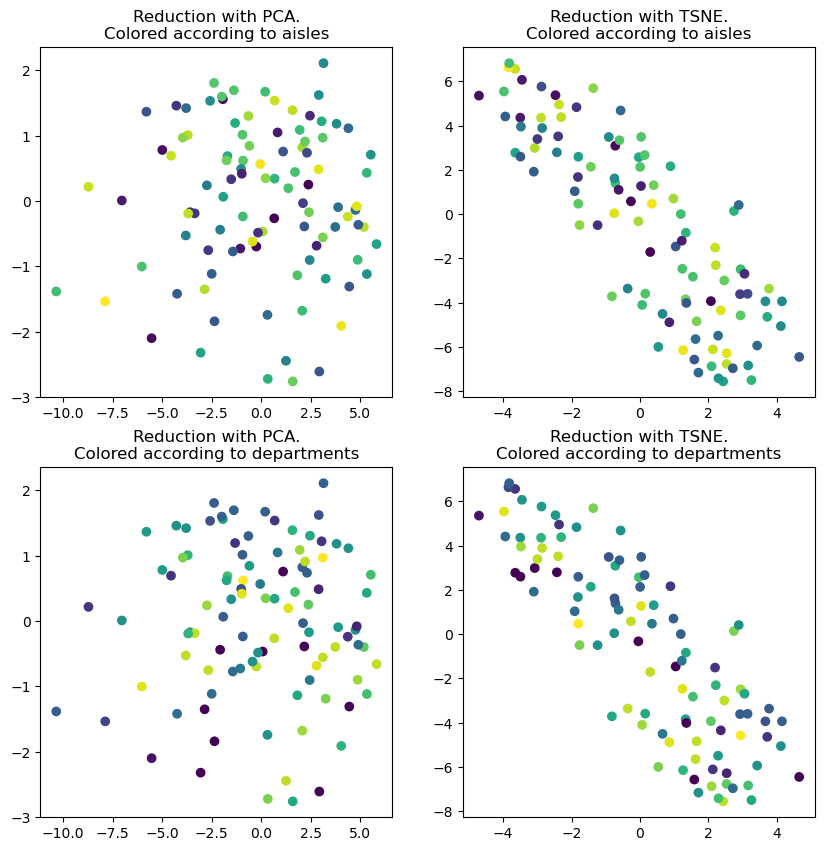

In [18]:
DimReduced_Plot(word_bert, data_points = data_points, dimensions = 2)

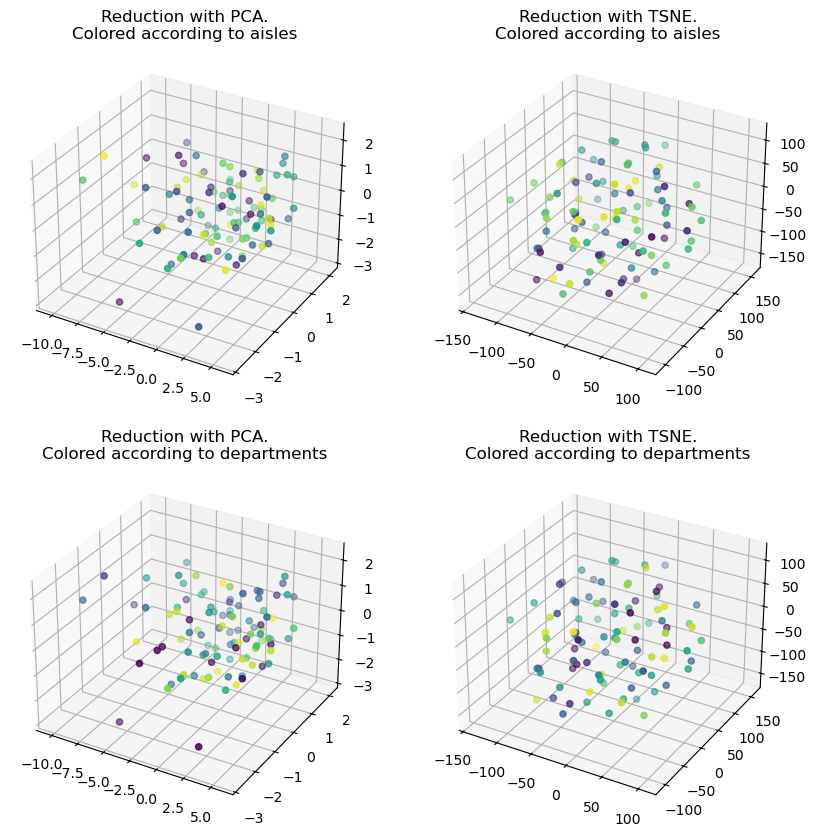

In [19]:
DimReduced_Plot(word_bert, data_points = data_points, dimensions = 3)

In [20]:
closest_neighbors_df = show_n_neighbors("bert_unaltered.ann", embedding_length = embedding_length_bert)
closest_neighbors_df

13.41% of neighbors are in the same aisle as the query product
27.17% of neighbors are in the same department as the query product


,Product_ID,Product_Name,Closest_Neighbor 1,Closest_Neighbor 2,Closest_Neighbor 3,Closest_Neighbor 4,Closest_Neighbor 5,Closest_Neighbor 6,Closest_Neighbor 7,Closest_Neighbor 8,Closest_Neighbor 9,Closest_Neighbor 10
0,23957,Sugar Free Vanilla Pudding,Organic Fuel High Protein Chocolate Shake,Strawberry Jel Dessert,Special K Touch of Honey Granola,Caramel Biscuits,Almond Toast Cookie,Special K Protein French Vanilla Shakes,Dulce De Leche Sugar Free Pudding,Super Lysine Plus Cream,Dark Chocolate Royale Shakes,Pure Seedless Strawberry Jam
1,15436,Espresso Bellavitano,Riserva Pasta Sauce Marinara,Mini Italian Eggplant,Milk Chocolate Caramel Sea Salt Bar,Mandarin Orange Kiwi,Coconut Thai Chai,Chewy Fudge Brownie Mix,Meat Lovers Lasagna,Herb & Butter Rice Mix,Belgian Chocolate Thins,Decaf Instant Coffee
2,48502,Three Cheese Shredded Cheese Cup,Cinnamon French Toaster Sticks,Shredded Extra Sharp Cheddar Cheese,Four Cheese Pizza Flaky Crust Frozen Snacks,Crunch Chocolate Peanut Butter Granola Bar,Pure Butter Chocolate Chip Shortbread,Chocolate Peanut Butter Crisp Energy Bar,Cheesecake Salted Caramel Cups,Chocolate Peanut Butter Protein Bar,Caramel Apple Pie Soft Cookies,Crunchy Peanut Butter Energy Bar
3,16830,Le Gruyere Cheese,Swiss Gruyere Cheese,Gruyere Cheese,Shredded Gruyere Cheese,Merlot BellaVitano Cheese,Labné Kefir Cheese,Labne Kefir Cheese,Apple Smoked Gruyere Cheese,Pecorino Toscano Cheese,Neufchatel Cheese,Neufchâtel Cheese
4,3342,Happy Hips Dog Food Duck & Sweet Potato Stew,Happy Hips Dog Food Lamb & Sweet Potato Stew,Pumpkin & Apple Flavor Dog Treats,Chicken Sesame Bbq Bar,Nacho Cheese & Bean Snacks,Roasted Vegetable & Goat Cheese Flatbread Crus...,Naturally Rising Crust Sausage & Pepperoni Pizza,Tomato Sauce & Three Cheese Pizza,Chunky Chicken Feast Cat Food,Nutrish Chicken Purrcata Cat Food,Chocolate Chip Cookie Dough Fruit & Nut Bars
5,42205,Organic Sweet Potato Fries,Sweet Potato Fries,Organic Cheddar Snack Mix,French Fries,Vegan Peanut Butter Smores,Whole Grain Lasagna Pasta,Organic Yellow Corn Tortilla Chips,Organic Chili Cayenne,Pickled Green Tomatoes,Organic Petite Diced Tomatoes,Organic Shredded Mild Cheddar
6,33693,Seasoned Tomato Sauce for Chili,Chopped Garlic,Peanut Butter Egg White Protein Bar,Fine Ground Sea Salt,Spicy Peanut Noodles,Italiano Tomato Sauce,Sweet & Sour Sauce,Sweet Heat Barbecue Sauce,Beef London Broil,Fresh Whole Garlic,Herring in Cream Sauce
7,5701,White Whole Wheat Flour,Whole Wheat Flour,Whole Wheat Pastry Flour,100% Whole Grain Whole Wheat Flour,Whole Grain Oat Flour,Chickpea Flour,100% Whole Grain White Whole Wheat Flour,Onion Powder,Whole Powdered Vitamin D Goat Milk,Butter with Canola Oil,Whole Wheat Cereal
8,39166,Organic Puffed Kamut Cereal,Organic Koala Crisp Chocolate Cereal,Crispy Rice Cereal,Organic Kale Balsamic Chicken Sausage,Organic Mid Season Heirloom Apple Sauce,Organic Naturally Brewed Soy Sauce,Organic Lasagna with Meat Sauce,Vanilla Multigrain Cereal,Organic Apple Chicken Sausage,Organic Hoisin Sauce,Caramel Pecan Brownies
9,5814,Chunky Jammin' Jerk Chicken with Rice & Beans ...,Chunky Baked Potato with Cheddar & Bacon Bits ...,Veggie Spaghetti Pasta,Chunky Hot Salsa,Classic Chicken Noodle Soup,Classic Chicken Noodle RTS Soup,Chipotle Chicken Mac & Cheese,Santa Fe Extra Lean Veggie Burger,Peanut Butter And Jelly Granola Bar,Skillet Sauces Creamy Parmesan Chicken,Flamin' Hot Flavored Corn Chips


# BERT (compressed) Performance

In [21]:
embedding_length_bert_compressed = 64

class BERT_Compression(torch.nn.Module):
    def __init__(self):
        super().__init__()

        self.base = bert_model
        self.compression1 = torch.nn.AvgPool2d(kernel_size = (30, 1), stride = (30, 1))
        self.flatten = torch.nn.Flatten()
        self.compression2 = torch.nn.AvgPool1d(kernel_size = 768//embedding_length_bert_compressed, stride = 768//embedding_length_bert_compressed)

    def forward(self, input_ids, attention_mask):
        output = self.base(input_ids, attention_mask)
        output = self.compression1(output.last_hidden_state)
        output = self.flatten(output)
        output = self.compression2(output)
        return output
        
    
bert_model_compr = BERT_Compression()

In [22]:
AnnoyTree = AnnoyIndex(embedding_length_bert_compressed, "euclidean")
filename = "bert_compression_avg.ann"
try:
    AnnoyTree.load(f"annoy/{filename}")
    print("Existing Tree found and loaded")
except:
    print("Tree does not exists yet. Start Creation")
    for i in tqdm(range(DF.shape[0])):
        ID = DF.iloc[i, 0]
        Text = DF.iloc[i, 1]
        token_dict =  tokenize_for_bert(Text)
        input_id = token_dict["input_ids"]
        attention_mask = token_dict["attention_mask"]
        output = bert_model_compr(input_id, attention_mask).detach()
        AnnoyTree.add_item(ID, output.flatten())
    
    AnnoyTree.build(20)
    AnnoyTree.save(f"annoy/{filename}")
finally:
    AnnoyTree.unload()
    print("Tree has been unloaded")

Existing Tree found and loaded
Tree has been unloaded


In [23]:
closest_neighbors_df = show_n_neighbors("bert_compression_avg.ann", embedding_length = embedding_length_bert_compressed)
closest_neighbors_df

30.54% of neighbors are in the same aisle as the query product
45.49% of neighbors are in the same department as the query product


,Product_ID,Product_Name,Closest_Neighbor 1,Closest_Neighbor 2,Closest_Neighbor 3,Closest_Neighbor 4,Closest_Neighbor 5,Closest_Neighbor 6,Closest_Neighbor 7,Closest_Neighbor 8,Closest_Neighbor 9,Closest_Neighbor 10
0,35346,Every 40+ Woman's One Daily Multivitamin,Every Woman's One Daily 40+ Multivitamin,Every Man's One Daily Multivitamin,Women's One Daily Multivitamin,Every Man's One Daily 40 Plus Tablet,Dailyfoods Men Over 40 One Daily Iron Free,"2\"" x 6\"" Unscented White Pillar Candle",Women Over 55 Multivitamin,Every Woman Multivitamin,3 in 1 Cedar & Citrus Soap For Every Man,Comfort Sheer 60 ct Assorted Posted 5/7/2014 V...
1,37139,Tamari Ginger Asian Dressing,Tamari Peanut Asian Dressing,Tamari Sesame Asian Dressing,Triple Ginger Teriyaki Sauce,High Fiber Tomato Basil Soup,Asiago & Cracked Peppercorn Dressing,Sesame Ginger Teriyaki Sauce,Garlic Lemon Caesar Dressing,Asian Chopped Salad with Dressing,Lemon Dill Tartar Sauce,Roka Blue Cheese Salad Dressing
2,15955,1pk 270ct Refill,2 Pk. Wand Refill,Scars Cream + SPF 30,Bounty 6 Dr 140ct Paper Towel,Dha 1000,72ct Chlorine Free Wipes Refill,Chocolate Pu Erh Tea 16 ct,CASCAD ACTION PACS REG 60CT,5 Grain Tempeh,Tree Free Napkins - 250 CT,Cld/Flu Van Chrry
3,10849,Hickory Smoked Ham,Hickory Smoked Bacon,Hickory Smoked Boneless Sliced Ham,Hickory Smoked Low Sodium Ham Steak,Lean Smoked Ham,Hickory Smoked Tuna Creations,Smoked Ham,Applewood Smoked Bacon Mashed,Smoked Honey Ham,Applewood Smoked Turkey Breast,Smoked Turkey Tails
4,19850,Mashed Potatoes Garlic ID 525 Refrigerated Sides,Gluten Free Fettuccini Roasted Garlic,Gluten Free Sweet Potato Ravioli,Gluten Free Parmesan & Garlic Bagel Chips,Gluten-Free Roasted Garlic Potato Chips,Roasted Garlic & Parmesan Baby Reds Mashed Pot...,Organic Kale Salad With Organic Sesame Vinagre...,Refried Beans With Spicy Chipotle,Caramelized Sweet Onion Yogurt Dressing,Salted Caramel Yoghurt,Mayonnaise Safflower
5,11934,Organic Greens & Apple Juice,Organic Fruit & Vegetable Juice,Organic Vibrant Probiotic Fruit Juice,Organic Apples & Blueberries Baby Food,Organic Raspberry Mate Energy Drink,Organic Orange Fruit Juice,Organic Super Beet Juice,Organic Grapefruit Juice,Organic Fruit Punch,Organic Fruit Snacks,Organic Sweet Potato Baby Food
6,44706,Entertainment Cracker Collection,Four Star Collection Entertainment Crackers,Gummies 5 Flavors,Cloud 9 Pancake Mix,Heritage Bites Cereal,SuperMoist White Cake Mix,Classic Cookie Collection,Ultimate Apricots,Ultimates Turtle Cookie Dough,Horseradish Bloody Mary Mix,Fancy Feast Elegant Medleys Shredded Fare Coll...
7,16691,"Wet & Dry Hair Tangle Tamer, Sweet Pear",Wildly Natural Seaweed Argan Shampoo Unscented,"Garbage Disposal Freshner & Cleaner, Thyme wit...","PODS HE Turbo Laundry Detergent Pacs, Spring M...",Garbage Disposal Freshener And Cleaner Tangeri...,Lemongrass & Tea Tree With Orange Peel Body Wash,PlugIns Scented Oil Refill Red Honeysuckle Nectar,Organic Baby Unscented Hand & Body Shikakai Soap,Organic Hand & Body Shikakai Soap Lemongrass &...,Organic Unsweetened OriginalWhite Tea,Rejuvenation Sweet Orange & Clove Travel Tin C...
8,34350,Heavy Duty Non-Stick Aluminum Foil 35 sq ft,Heavy Duty Aluminum Foil 50 Sq. Ft.,Heavy Duty Foil 50 sq ft,Double Thick Adhesive Duct Tape 1.88 Inches X ...,Multipurpose Sealing Wrap 70 Sq. Ft.,Smoothers Concealer - 705 Fair,"Heavy Duty 18\"" Aluminium Foil","Heavy Duty 12\"" Aluminium Foil","Streak-Free Clean + Protect, Stainless Steel",Heavy Duty Aluminum Foil,Heavy Duty Fabric Refresher - Crisp Clean
9,14240,Organic Sunflower Butter Chocolate Macrobar,Organic Hazelnut Chocolate Butter,Organic Chewy Dark Chocolate Almond Granola Bars,Organic Chocolate Hazelnut Fig Granola,Organic Peanut Butter Chocolate Chip Granola,Organic Chocolate Coconut Milk,Organic Chocolate Toasted Coconut Brownie Brittle,Organic Raspberry Nib Crunch Dark Chocolate,Organic Peanut Butter Milk Chocolate Bar,Raw Protein and Greens Chocolate Organic Plant...,Organic Peanut Butter Granola


# BERT (trained further) Performance

## Expand the BERT Model and train these additional layers

In [57]:
class Hyperparameters:
    encoding_max_length = 30
    batch_size = 100
    # Train : Val : Test -> 0.8 : 0.1 : 0.1
    test_size = 0.2
    train_size = 0.75
    num_epochs = 200
    earlyStop_MinValLoss = 1e-5
    earlyStop_WaitingEpochs = 20
    lr = 1e-4
    lr_decay = 0.5
    lr_decay_epoch_waiting = 3
    lr_decay_threshold = 1e-3
    l2_regularizer = 1e-5
    gradient_clip_val = 1.0
    
hp = Hyperparameters()

In [58]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import ReduceLROnPlateau, StepLR
import os

In [ ]:
# Define a custom dataset
first = tokenize_for_bert(DF.iloc[0, 1], hp.encoding_max_length)
input_ids = first["input_ids"]
attention_masks = first["attention_mask"]
for i in tqdm(range(1, DF.shape[0])):
    new = tokenize_for_bert(DF.iloc[i, 1], hp.encoding_max_length)
    input_ids = torch.concatenate((input_ids, new["input_ids"]), axis = 0)
    attention_masks = torch.concatenate((attention_masks, new["attention_mask"]), axis = 0)

In [60]:
labels = (DF.loc[:, "department_id"] - 1).to_list() # the deparment IDs start at 1, but for the sake of the training they must start at 0
ids = DF.loc[:, "product_id"]

In [61]:
###### Pre-Tokenize the Entire Dataset
class TextDataset(Dataset):
    def __init__(self, embedding, labels, product_ids = None):
        self.product_ids = product_ids 
        self.labels = labels
        self.embedding = embedding
 
    def __len__(self):
        return len(self.labels)
 
    def __getitem__(self, idx):
        if not (self.product_ids is None):
            product_id = self.product_ids.iloc[idx]
        embedding = self.embedding[idx, :]
        label = self.labels[idx]

        if not(self.product_ids is None):
            return {
                'product_ids': product_id,
                "embedding": embedding,
                'labels': torch.tensor(label, dtype=torch.long)
            }
        else:
            return {
                "embedding": embedding,
                'labels': torch.tensor(label, dtype=torch.long)
            }
 
# Define a classification model
class BertClassifier(nn.Module):
    def __init__(self, bert_base_model):
        super(BertClassifier, self).__init__()
        self.bert = bert_base_model

        ## The Compression which already proved to drastically increase teh performance of grouping Items to other Items in the same department/aisle
        self.compression1 = torch.nn.AvgPool2d(kernel_size = (30, 1), stride = (30, 1))
        self.flatten = torch.nn.Flatten()
        self.compression2 = torch.nn.AvgPool1d(kernel_size = 768//embedding_length_bert_compressed, stride = 768//embedding_length_bert_compressed)

        # freeze all layers
        for param in self.bert.parameters():
            param.requires_grad = False
            
        # # reactivate gradient for the last pooler layer
        # for param in self.bert.pooler.parameters():
        #     param.requires_grad = True
        

 
    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
            output = output.pooler_output
            # output = self.compression1(output.last_hidden_state)
            # output = self.flatten(output)
            # output = self.compression2(output)
      
            return output



class Linear_Block(nn.Module):
    def __init__(self, in_nodes, out_nodes, activ = "SELU"):
        super().__init__()
        self.fc1 = nn.Linear(in_nodes, in_nodes)
        self.fc2 = nn.Linear(in_nodes, out_nodes)

        self.skip = nn.Identity() if in_nodes == out_nodes else nn.Linear(in_nodes, out_nodes)

        if activ == "SELU":
            self.activ_f = nn.SELU()
            for layer in [self.fc1, self.fc2, self.skip]:
                if isinstance(layer, nn.Linear):
                    nn.init.kaiming_uniform_(layer.weight, mode='fan_in', nonlinearity='selu')
        elif activ == "Tanh":
            self.activ_f = nn.Tanh()
            for layer in [self.fc1, self.fc2, self.skip]:
                if isinstance(layer, nn.Linear):
                    nn.init.xavier_uniform_(layer.weight)
                    nn.init.zeros_(layer.bias)

        self.norm1 = nn.BatchNorm1d(in_nodes)
        self.norm2 = nn.BatchNorm1d(out_nodes)
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        skip = self.skip(x)
        x = self.fc1(x)
        x = self.norm1(x)
        x = self.activ_f(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.norm2(x) + skip
        x = self.activ_f(x)
        x = self.dropout(x)
        return x

class ExtraLayers(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        base_nodes = 768 # 64
        self.fc1 = Linear_Block(base_nodes, base_nodes*3)
        self.fc2 = Linear_Block(base_nodes*3, base_nodes*2)
        self.out = nn.Linear(base_nodes*2, num_classes)
 
    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        logits = self.out(x)
        return logits


Nr of training samples (before oversampling): 29812
Nr of validation samples: 9938
Nr of testing samples: 9938


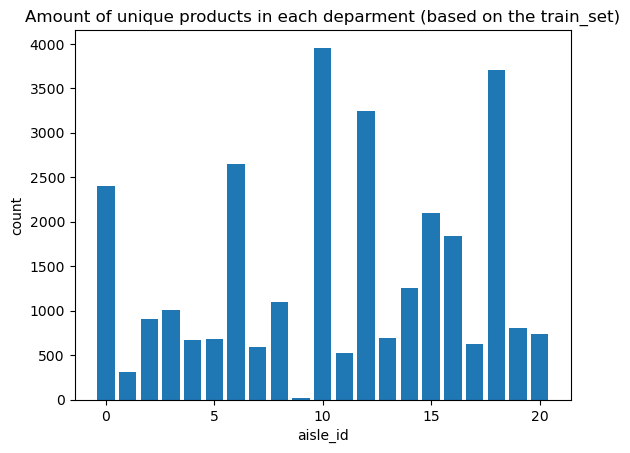

Class weights calculated


In [63]:
test_size = hp.test_size
train_size = hp.train_size

random_seed = 42
id_train, id_test, input_ids_train, input_ids_test, attention_mask_train, attention_mask_test, y_train, y_test = train_test_split(ids, input_ids, attention_masks, labels, test_size = test_size, random_state = random_seed)
id_train, id_val, input_ids_train, input_ids_val, attention_mask_train, attention_mask_val, y_train, y_val = train_test_split(id_train, input_ids_train, attention_mask_train, y_train, train_size = train_size, random_state = random_seed)
print(f"Nr of training samples (before oversampling): {len(id_train)}")
print(f"Nr of validation samples: {len(id_val)}")
print(f"Nr of testing samples: {len(id_test)}")

unique_labels, count = np.unique(y_train, return_counts = True)
num_classes = len(np.unique(unique_labels))

fig = plt.figure()
ax = fig.add_subplot()
ax.bar(unique_labels, count)
ax.set_xlabel("aisle_id")
ax.set_ylabel("count")
ax.set_title("Amount of unique products in each deparment (based on the train_set)")
plt.show()

# if not ("Best_Epoch.pt" in os.listdir("ModelCheckpoints")):
#     true_labels = y_train.copy()
#     for i, c in tqdm(enumerate(count), desc = "Oversampling", total = len(count)):
#         if c == np.max(count):
#             continue
#         gap = np.max(count) - c
#         current_label = unique_labels[i]
#         choice_mask = true_labels == current_label
#         duplication_indices = np.random.choice(np.arange(len(true_labels))[choice_mask], size = gap)
#         for j in duplication_indices:
#             input_ids_train = torch.concatenate((input_ids_train, input_ids_train[j, :][None, :]), dim = 0)
#             attention_mask_train = torch.concatenate((attention_mask_train, attention_mask_train[j, :][None, :]), dim = 0)
#             y_train.append(true_labels[j])
    
#     print(f"Nr of training samples (after oversampling): {len(y_train)}")


total_samples = len(input_ids)
class_weights = total_samples / (num_classes * count)
class_weights = torch.tensor(class_weights / np.sum(class_weights)).type(torch.float)
print("Class weights calculated")

In [29]:
embedding_model = BertClassifier(bert_model)
steps = 100

if not ("Best_Epoch.pt" in os.listdir("ModelCheckpoints")):
    embedding_train = []
    for i in tqdm(range(0, input_ids_train.shape[0]-steps, steps), desc = "Embedding of Training"):
        embedding_train.append(embedding_model(input_ids_train[i:i+steps, :], attention_mask_train[i:i+steps, :]))
    embedding_train.append(embedding_model(input_ids_train[i+steps:, :], attention_mask_train[i+steps:, :]))
    embedding_train = torch.concatenate(embedding_train, dim = 0)



Embedding of Training: 100%|█████████████████████████████████████████████████████████| 298/298 [08:57<00:00,  1.80s/it]


In [30]:
if not ("Best_Epoch.pt" in os.listdir("ModelCheckpoints")):
    embedding_val = []
    for i in tqdm(range(0, input_ids_val.shape[0]-steps, steps), desc = "Embedding of Validation"):
        embedding_val.append(embedding_model(input_ids_val[i:i+steps, :], attention_mask_val[i:i+steps, :]))
    embedding_val.append(embedding_model(input_ids_val[i+steps:, :], attention_mask_val[i+steps:, :]))
    embedding_val = torch.concatenate(embedding_val, dim = 0)

Embedding of Validation: 100%|█████████████████████████████████████████████████████████| 99/99 [02:56<00:00,  1.78s/it]


In [31]:
embedding_test = []
for i in tqdm(range(0, input_ids_test.shape[0]-steps, steps), desc = "Embedding of Testing"):
    embedding_test.append(embedding_model(input_ids_test[i:i+steps, :], attention_mask_test[i:i+steps, :]))
embedding_test.append(embedding_model(input_ids_test[i+steps:, :], attention_mask_test[i+steps:, :]))
embedding_test = torch.concatenate(embedding_test, dim = 0)

Embedding of Testing: 100%|████████████████████████████████████████████████████████████| 99/99 [03:03<00:00,  1.85s/it]


In [64]:
# Initialize the dataset
if not ("Best_Epoch.pt" in os.listdir("ModelCheckpoints")):
    train_loader = DataLoader(
        TextDataset(embedding_train, y_train),
        batch_size=hp.batch_size,
        shuffle=True) 
    
    val_loader = DataLoader(
        TextDataset(embedding_val, y_val),
        batch_size=hp.batch_size,
        shuffle=False)

test_loader = DataLoader(
    TextDataset(embedding_test, y_test, id_test),
    batch_size=hp.batch_size,
    shuffle=False) 

class CustomLoss(nn.Module):
    def __init__(self, dataloader, n = 10, weights = None):
        super().__init__()
        self.neighbors = n
        self.dataloader = dataloader
        criterion = nn.CrossEntropyLoss(weight = weights)#  Custom_Loss()

    def euclidean_distance(self, sample, embeddings):
        return torch.sqrt(torch.sum(torch.square(sample.repeat(embeddings.shape[0], 1) - embeddings), dim = 1))

    def forward(self, logits, true_labels, model):
        """
        Find the n closest products and determine the overall loss and accuracy based on them
        """
        ##### Prep #####
        embeddings = []
        labels = []
        with torch.no_grad():
            for batch in self.dataloader:
                batch_embedding = batch["embedding"]
                batch_labels = batch['labels']
                embeddings.append(model(batch_embedding))
                labels.append(batch_labels)
        embeddings = torch.concatenate(embeddings, dim = 0)
        
        labels = torch.concatenate(labels, dim = 0)

        #####
        loss = 0
        acc = 0
        for i in range(logits.shape[0]):
            subset = logits[i, :][None, :]
            distances = self.euclidean_distance(subset, embeddings)
            closest_neighbors_indices = torch.argsort(distances, descending = False)[1:self.neighbors+1] # not interested in the distance of a sample with itself
            loss += criterion(subset.repeat(self.neighbors, 1), embeddings[closest_neighbors_indices, :])
            acc += np.mean((true_labels[i].repeat(self.neighbors).flatten().numpy() == labels[closest_neighbors_indices.tolist()].numpy().flatten()).astype(np.int16))

        loss /= logits.shape[0]
        acc /= logits.shape[0]

        return loss, acc

In [65]:
# # Initialize the model, loss function, and optimizer
model = ExtraLayers(num_classes = num_classes)
if not ("Best_Epoch.pt" in os.listdir("ModelCheckpoints")):
    try:
        last_epoch = np.max([int(i.split("_")[1].replace(".pt", "")) for i in os.listdir("ModelCheckpoints") if i.startswith("Epoch")])
        checkpoint = f"ModelCheckpoints/Epoch_{last_epoch}.pt"
        start = last_epoch + 1
        model.load_state_dict(torch.load(checkpoint, weights_only = False))
        print("Checkpoint loaded")
        with open("ModelCheckpoints/loss.txt", "r") as f:
            past_losses = [float(i.split('\t')[-1].split(":")[-1].replace("\n", "")) for i in f.readlines()]
        earlyStop_BestValLoss = np.min(past_losses)
        earlyStop_BestEpoch = past_losses.index(earlyStop_BestValLoss)
        earlyStop_EpochCounter = len(past_losses) - earlyStop_BestEpoch - 1
        
        
    except Exception as e:
        # print(e)
        start = 0
        earlyStop_EpochCounter = 0
        earlyStop_BestValLoss = np.inf
        earlyStop_BestEpoch = 0
        print("Start new training")
    
    
    
    # criterion = nn.CrossEntropyLoss()#  Custom_Loss()
    train_criterion  = nn.CrossEntropyLoss(weight = class_weights)
    val_criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=hp.lr, weight_decay = hp.l2_regularizer)
    optimizer.zero_grad()
    # scheduler = StepLR(optimizer, gamma=hp.lr_decay, step_size=hp.lr_decay_epoch_waiting)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=hp.lr_decay, patience=hp.lr_decay_epoch_waiting, threshold = hp.lr_decay_threshold)
    # gradient_accumulation = 50
     
    # Training loop
    
    if start >= hp.num_epochs or earlyStop_EpochCounter >= hp.earlyStop_WaitingEpochs:
        print("Model already trained")
    else:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model.to(device)
    
        
        for epoch in range(start, hp.num_epochs):
            train_loss = 0
            train_acc = 0
            val_loss = 0
            val_acc = 0
            batch_counter = 0
            
            for batch in tqdm(train_loader, desc = f"Epoch {epoch+1:03}"):
                batch_counter += 1
                batch_embedding = batch["embedding"]
                batch_labels = batch['labels']
    
                # with torch.no_grad():
                outputs = model(batch_embedding)
                #### Compare the embedding of each text to hp.comparisons embeddings of texts from the same class and from a different class
                # loss += criterion(outputs, batch_labels)
                batch_loss = train_criterion(outputs, batch_labels)
                train_loss += batch_loss
                
                # train_losses.append(loss.detach())
                batch_acc = np.mean((torch.argmax(outputs.detach(), dim = 1).numpy().flatten() == batch_labels.numpy().flatten()).astype(np.int16))
                train_acc += batch_acc
                # train_accs.append(acc)
            # if batch_counter % gradient_accumulation == 0:
            train_loss /= batch_counter
            train_loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=hp.gradient_clip_val)
            optimizer.step()
            optimizer.zero_grad()
            train_acc /= batch_counter
            train_loss = train_loss.detach()
                
                

            
            batch_counter = 0
            with torch.no_grad():
                for batch in tqdm(val_loader, desc = "Validation"):
                    batch_counter += 1
                    batch_embedding = batch["embedding"]
                    batch_labels = batch['labels']
                    outputs = model(batch_embedding)

                    batch_loss = train_criterion(outputs, batch_labels)
                    val_loss += batch_loss
                    # loss = criterion(outputs, batch_labels)
                    # val_losses.append(loss.detach())
                    batch_acc = np.mean((torch.argmax(outputs.detach(), dim = 1).numpy().flatten() == batch_labels.numpy().flatten()).astype(np.int16))
                    val_acc += batch_acc
                    # val_accs.append(acc)
            val_loss /= batch_counter
            val_acc /= batch_counter
            
            scheduler.step(train_loss)
    
            if val_loss + hp.earlyStop_MinValLoss < earlyStop_BestValLoss:
                earlyStop_BestValLoss = val_loss
                earlyStop_EpochCounter = 0
                earlyStop_BestEpoch = epoch
            else:
                earlyStop_EpochCounter += 1
                
            with open("ModelCheckpoints/loss.txt", "a") as f:
                f.write(f"Epoch:{epoch:03}\tTrainLoss:{train_loss:.10f}\tValLoss:{val_loss:.10f}\n")
            torch.save(model.state_dict(), f"ModelCheckpoints/Epoch_{epoch}.pt")
            print(f'Epoch {epoch+1}/{hp.num_epochs}, Training Loss: {train_loss:.10f}, Validation Loss: {val_loss:.10f}, Training Accuracy: {train_acc:.2%}, Validation Accuracy: {val_acc:.2%}')
    
            if earlyStop_EpochCounter >= hp.earlyStop_WaitingEpochs:
                print(f"EarlyStop has been triggered. Stop training.\nBest Epoch: {earlyStop_BestEpoch} (considering that 000 ist the first epoch).")
                break
    
        import shutil
        shutil.copy2(f"ModelCheckpoints/Epoch_{earlyStop_BestEpoch}.pt", f"ModelCheckpoints/Best_Epoch.pt")
else:
    print("Model has already been trained.")

Start new training


Validation: 100%|████████████████████████████████████████████████████████████████████| 100/100 [00:02<00:00, 38.79it/s]


Epoch 1/200, Training Loss: 3.3334784508, Validation Loss: 3.0915486813, Training Accuracy: 5.76%, Validation Accuracy: 12.82%


Validation: 100%|████████████████████████████████████████████████████████████████████| 100/100 [00:02<00:00, 39.06it/s]


Epoch 2/200, Training Loss: 3.0895841122, Validation Loss: 2.7765090466, Training Accuracy: 13.05%, Validation Accuracy: 18.12%


...

Epoch 86/200, Training Loss: 1.2109915018, Validation Loss: 1.7065330744, Training Accuracy: 59.32%, Validation Accuracy: 54.89%


Validation: 100%|████████████████████████████████████████████████████████████████████| 100/100 [00:02<00:00, 38.17it/s]


Epoch 87/200, Training Loss: 1.2093530893, Validation Loss: 1.7264715433, Training Accuracy: 59.42%, Validation Accuracy: 55.01%


Validation: 100%|████████████████████████████████████████████████████████████████████| 100/100 [00:02<00:00, 36.87it/s]

Epoch 88/200, Training Loss: 1.2041742802, Validation Loss: 1.7338032722, Training Accuracy: 59.71%, Validation Accuracy: 54.70%
EarlyStop has been triggered. Stop training.
Best Epoch: 67 (considering that 000 ist the first epoch).


## Check Performance on the Test Group

In [66]:
model.load_state_dict(torch.load("ModelCheckpoints/Best_Epoch.pt", weights_only = False))
# model.fc = nn.Identity() # Just like with the previous models, I am interested in the Final Embedding. Therefore, I replace the output layer with an identity layer

<All keys matched successfully>

In [67]:
AnnoyTree = AnnoyIndex(num_classes, "euclidean")
filename = "bert_training.ann"
test_ids = []
try:
    AnnoyTree.load(f"annoy/{filename}")
    print("Existing Tree found and loaded")
except:
    print("Tree does not exists yet. Start Creation")
    for batch in tqdm(test_loader):
        batch_embedding = batch["embedding"]
        product_ids = batch["product_ids"]
        with torch.no_grad():
            output = model(batch_embedding)
            for i in range(batch_embedding.shape[0]):
                AnnoyTree.add_item(product_ids[i], output[i, :].flatten())
                test_ids.append(product_ids[i])
    
    AnnoyTree.build(100)
    AnnoyTree.save(f"annoy/{filename}")
finally:
    AnnoyTree.unload()
    print("Tree has been unloaded")

Tree does not exists yet. Start Creation


100%|████████████████████████████████████████████████████████████████████████████████| 100/100 [00:03<00:00, 27.27it/s]


Tree has been unloaded


In [68]:
closest_neighbors_df = show_n_neighbors("bert_training.ann", embedding_length = num_classes, id_list = test_ids)
closest_neighbors_df

15.10% of neighbors are in the same aisle as the query product
38.05% of neighbors are in the same department as the query product


,Product_ID,Product_Name,Closest_Neighbor 1,Closest_Neighbor 2,Closest_Neighbor 3,Closest_Neighbor 4,Closest_Neighbor 5,Closest_Neighbor 6,Closest_Neighbor 7,Closest_Neighbor 8,Closest_Neighbor 9,Closest_Neighbor 10
0,31396,French Vanilla Sugar Free Coffee Creamer,Sugar Free Hazelnut Coffee Creamer,Lactose Free Vanilla Ice Cream,Slow Churned Fat Free Yogurt Blends Vanilla,Sugar Free Italian Sweet Creme Coffee Creamer,Vanilla Blended Non-Fat Greek Yogurt,Fat Free Blueberry Yogurt,Hazelnut Dairy Free Almond Milk Creamer,Cold Brewed Cinnamon Coffee Non Dairy Ice Cream,Drinkable Yogurt Starwberry,Sugar-Free Whipped Heavy Cream
1,20171,White Bread,Jewish Rye Bread,Light Italian Bread,Multigrain Baguette,Enriched White Bread,Rich Frosted Donuts,Borscht,White Gold Popcorn,Cherry Pie,Marble Rye Bread,Small Enriched Bread
2,37618,Calm Banana Pumpkin Coconut Blackberry Vanilla...,Mixed Chocolate Candy Variety Pack,"Gummi Candy, Fizzy Cola",Mint To Be Ice Cream,Coffee Caramel Ice Cream,Original Cashew Milk,Mighty Mango Juice Smoothie,Special K Protein Greek Yogurt And Fruit Bar 4...,Vanilla Premium Ice Cream,Bright Beet Juice Smoothie,"Coco-Roons, Mini, Vanilla Maple"
3,30760,Children's Natural Grape Flavor Cough Syrup,Zero Go-Go Mixed Berry Vitamin Water,Berry Boost 100% Fruit Juice Smoothie + Boosts,Organic Lemon Flavor Recharge Thirst Quencher ...,Standardized Elderberry Syrup Berry Flavor,Children's Grape Flavor Nighttime Cough Syrup,Electrolyte Hydrator Lemon Lime,"1,000 Mg Vitamin C Lemon Lime Effervescent Dri...",Original No Pulp Pure 100% Florida Orange Juice,Infusions Strawberry Basil Flavor Enhancer,Fruit Punch Liquid Water Enhancer
4,4645,Queso Blanco Medium Dip,Medium Guacamole Salsa,Star Wars Macaroni and Cheese,Kalamata Greek Olives,Nacho Cheddar Seasoning,Mild Salsa Roja,"Mustard, Hot Dijon",Lightly Salted Edamame,Chianti Classico,Greek Yogurt Dressing Cucumber Dill,Hard Deli Salami
5,29391,Organic 2nd Foods Apples & Summer Peaches Bab...,Stage 2 Apple Turkey Cranberry Baby Food,Mangos Organic Baby Food,Organic 4 Months Butternut Squash Carrots Appl...,Organic 2nd Foods Carrots Apples & Mangoes Bab...,Baby 2nd Foods Apples & Chicken,"Organic Baby Food Sweet Potato Apple, Grape & ...",Apple and Blueberry Organic Baby Food,"Organic 3rd Foods Apples, Prunes & Oranges wit...",Stage 2 Pear Pumpkin Baby Food,Organic Apple Wild Blueberry Baby Food
6,5166,Gluten Free Banana Bread Mix,Organic Hazelnut Hemp Cacao Superfoods Bar,Eggo Thick & Fluffy Cinnamon Brown Sugar Waffles,Corn Bread & Muffin Mix,Dairy Free Coconut Almondmilk Blend,Brown Sugar Cinnamon Pre-Sliced Mini Bagels,Strawberry with Kellogg's Granola,Gluten Free Hard Candies Honey,Sugar Free Strawberry-Banana Low Calorie Gelat...,Chocolate Cake Mix Gluten-Free Non-Dairy,Baby Mum-Mum Banana Rice Rusks
7,16891,Fun Size Candy Bars,Dark Chocolate Nuts & Sea Salt Bars,Original Potato Chips Triple Pack,Sweet & Spicy Granola Bars,PayDay Peanut Caramel Candy Bars Snack Size,Fun Size Butterfinger Candy Bar,Giant Chocolate Fudge Ice Cream Bars,Fun Size Bag Mixed Chocolate Candy,Candy Rolls Assorted Flavors,Protein Energy Bar Original Peanut Butter Creme,Watermelon Gummy Candy
8,20504,Cheese Creations Double Cheddar Sauce,Chunky Healthy Request Old Fashioned Vegetable...,"Broccoli, Carrots, Cauliflower, & Cheese Sauce",Macaroni & Cheese Sauce with Broccoli Steamers,Pasta with Swedish Meatballs Tasty American Fa...,Organic Poultry Seasoning,Crushed Italian Recipe with Oregano & Basil To...,Macaroni & Cheese Tasty American Favorites,Sun Bird Beef and Broccoli Seasoning Mix,Fat Free Ranch Veggie Dip,Ready Snax Veggie & Cheese With Ranch Dip
9,45820,Classic Mouthwash,Even Advanced Sea Algae Enzume Scrub,Allergy Eye Relief,Organic Mint Leaves,Organic Ground Mace,Garlic Herb & Wine Marinade,Pink Salt Rock with Grater,Organic Cilantro Bunch,Spicy Homestyle 7 Spice Chili Starter,Plant Enzymes,Vinyl Gloves


# RFC on top of BERT

In [70]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(n_estimators = 100, max_depth=10, min_samples_leaf=20, min_impurity_decrease = 1e-3, class_weight = {Class:weight for Class, weight in enumerate(class_weights)})
rfc.fit(embedding_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,20
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.001
,bootstrap,True
,oob_score,False


In [71]:
rfc.score(embedding_train, y_train)*100

24.037300415939892

In [72]:
rfc.score(embedding_val, y_val)*100

22.881867578989738

In [73]:
rfc.score(embedding_test, y_test)*100

21.261823304487827